In [567]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
plt.rcParams.update({'font.size': 10})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 
from sps_common.constants import DM_CONSTANT, FREQ_BOTTOM, FREQ_TOP, TSAMP
from ps_processes.processes.ps_inject import gaussian
from scipy.fft import rfft

In [572]:
data_1 = np.concatenate((np.loadtxt('single_day_20260402_results.txt'),
                         np.loadtxt('single_day_2026_04_05_injections.txt'),
                         np.loadtxt('single_day_2026_04_08_injections.txt')))
data_1[:, 2] = 1
data_5 = np.loadtxt('5_day_injections.txt')
data_6 = np.loadtxt('6_day_injections.txt')
data_7 = np.loadtxt('7_day_injections.txt')
data_8 = np.loadtxt('8_day_injections.txt')
data_9 = np.loadtxt('9_day_injections.txt')
data_10 = np.loadtxt('10_day_injections.txt')
data_11 = np.loadtxt('11_day_injections.txt')
data_12 = np.loadtxt('12_day_injections.txt')
data_13 = np.loadtxt('13_day_injections.txt')
data_14 = np.loadtxt('14_day_injections.txt')
data_15 = np.loadtxt('15_day_injections.txt')
data_16 = np.loadtxt('16_day_injections.txt')
data_17 = np.loadtxt('17_day_injections.txt')
data_18 = np.loadtxt('18_day_injections.txt')
data_19 = np.loadtxt('19_day_injections.txt')
data_20 = np.loadtxt('20_day_injections.txt')

data = [data_1, #data_5, 
        #data_6, 
        #data_7, data_8, 
        data_9,
         data_10, data_11, 
        data_12, 
        data_13, 
        data_14, data_15, data_16,
        data_17, data_18, data_19, data_20]

In [573]:
p_total = []
days = []

for datum in data:
    p = len(datum[datum[:, -1] > 0.]) / len(datum)
    print(f'{int(datum[0, 2])}-day stack: {len(datum)} injections, p({int(datum[0, 2])}) = {p:.2f}')
    p_total.append(p)
    days.append(datum[0, 2])

days = np.array(days)

1-day stack: 28619 injections, p(1) = 0.28
9-day stack: 3153 injections, p(9) = 0.40
10-day stack: 9360 injections, p(10) = 0.37
11-day stack: 26248 injections, p(11) = 0.39
12-day stack: 49097 injections, p(12) = 0.40
13-day stack: 75732 injections, p(13) = 0.41
14-day stack: 47570 injections, p(14) = 0.40
15-day stack: 11392 injections, p(15) = 0.39
16-day stack: 25036 injections, p(16) = 0.41
17-day stack: 19005 injections, p(17) = 0.40
18-day stack: 36026 injections, p(18) = 0.42
19-day stack: 32595 injections, p(19) = 0.42
20-day stack: 8533 injections, p(20) = 0.42


Text(0, 0.5, 'p(N)')

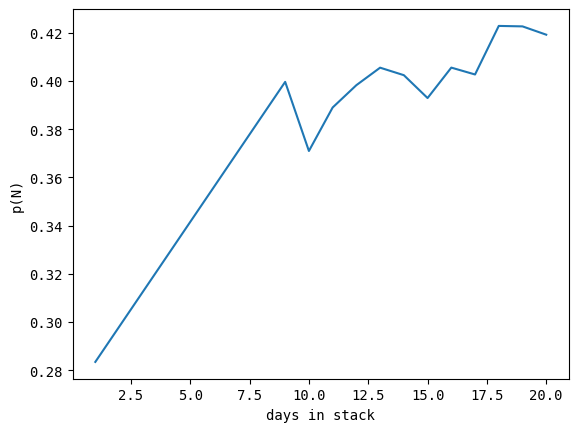

In [574]:
plt.plot(days, p_total)
plt.xlabel('days in stack')
plt.ylabel('p(N)')

/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:34: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected


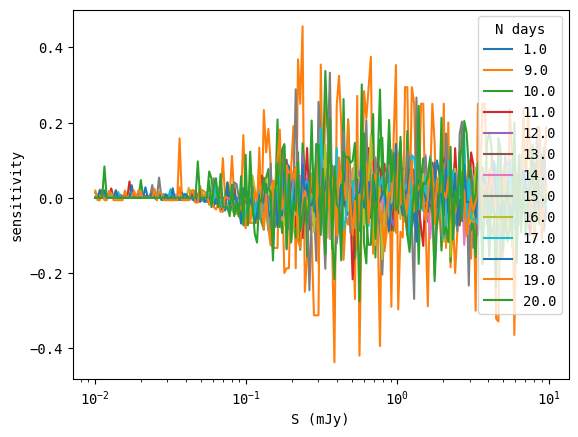

In [575]:
S_idx = 6
S_bins = np.logspace(-2, 1, 200)
S_dev = 10

S_curve = np.zeros((len(data), len(S_bins) - 1))
S_80 = np.zeros(len(data))
S_10 = np.zeros(len(data))
S_1 = np.zeros(len(data))
S_err50_up = np.zeros(len(data))
S_err10_up = np.zeros(len(data))
S_err10_down = np.zeros(len(data))
S_err1_up = np.zeros(len(data))
S_err1_down = np.zeros(len(data))

for i in range(len(data)):

    _, S_sens, S_smooth = au.get_sensitivity(
        data[i],
        *(S_idx, S_bins, S_dev)
    )

    plt.plot(S_bins[:-1], S_sens - S_smooth, label = days[i])
    # plt.plot(S_bins[:-1], S_smooth, '--')
    # plt.plot(S_bins[:-1], S_sens - S_smooth, '--')

    S_curve[i] = S_sens
    #S_smooth = gaussian_filter(S_sens, 3)
    S_80[i] = np.max(S_bins[np.where(S_smooth < 0.5)[0]])
    S_10[i] = np.max(S_bins[np.where(S_smooth < 0.1)[0]])
    S_1[i] = np.max(S_bins[np.where(S_smooth < 0.01)[0]])

    p_80_idx = np.where(S_smooth < 0.5)[0][-1]
    local_std50 = np.std(S_sens[p_80_idx - 10: p_80_idx + 10])
    S_err50_up[i] = np.max(S_bins[np.where(S_smooth < 0.5 + local_std50)[0]])

    p_10_idx = np.where(S_smooth < 0.1)[0][-1]
    local_std10 = np.std(S_sens[p_10_idx - 10:p_10_idx + 10])
    S_err10_up[i] = np.max(S_bins[np.where(S_smooth < 0.1 + local_std10)[0]])
    try:
        S_err10_down[i] = np.max(S_bins[np.where(S_smooth < 0.1 - local_std10)[0]])
    except:
        S_err10_down[i] = np.nan
    p_1_idx = np.where(S_smooth < 0.01)[0][-1]
    local_std1 = np.std(S_sens[p_1_idx - 12:p_1_idx + 12])
    S_err1_up[i] = np.max(S_bins[np.where(S_smooth < 0.01 + local_std1)[0]])
    try:
        S_err1_down[i] = np.max(S_bins[np.where(S_smooth < 0.01 - local_std1)[0]])
    except:
        S_err1_down[i] = np.nan

S_err10_down = S_10 - S_err10_down 
S_err10_up -= S_10 
S_err1_down = S_1 - S_err1_down 
S_err1_up -= S_1
S_err50_up -= S_80

#plt.plot(S_bins[:-1], S_sens - S_smooth, label = days[i])
plt.xlabel('S (mJy)')
plt.ylabel('sensitivity')
plt.legend(title = 'N days')
plt.xscale('log')

In [576]:
def analytical_curve_10(x, alpha):

    return S_10[0] * x**alpha

def analytical_curve_1(x, alpha):

    return S_1[0] * x**alpha

def analytical_curve_80(x, alpha):

    return S_80[0] * x**alpha

alpha_10, err10 = curve_fit(analytical_curve_10, days, S_10, p0 = -0.5, sigma = S_err10_up)
alpha_1, err1 = curve_fit(analytical_curve_1, days, S_1, p0 = alpha_10, sigma = S_err1_up)
alpha_80, err50 = curve_fit(analytical_curve_80, days, S_80, p0 = alpha_10, sigma = S_err50_up)
print(f'80%: {alpha_80[0]:.2f} +- {err50[0][0]:.3f}')
print(f'10%: {alpha_10[0]:.2f} +- {err10[0][0]:.3f}')
print(f'1%: {alpha_1[0]:.2f} +- {err1[0][0]:.3f}')

80%: -0.43 +- 0.000
10%: -0.42 +- 0.000
1%: -0.39 +- 0.000


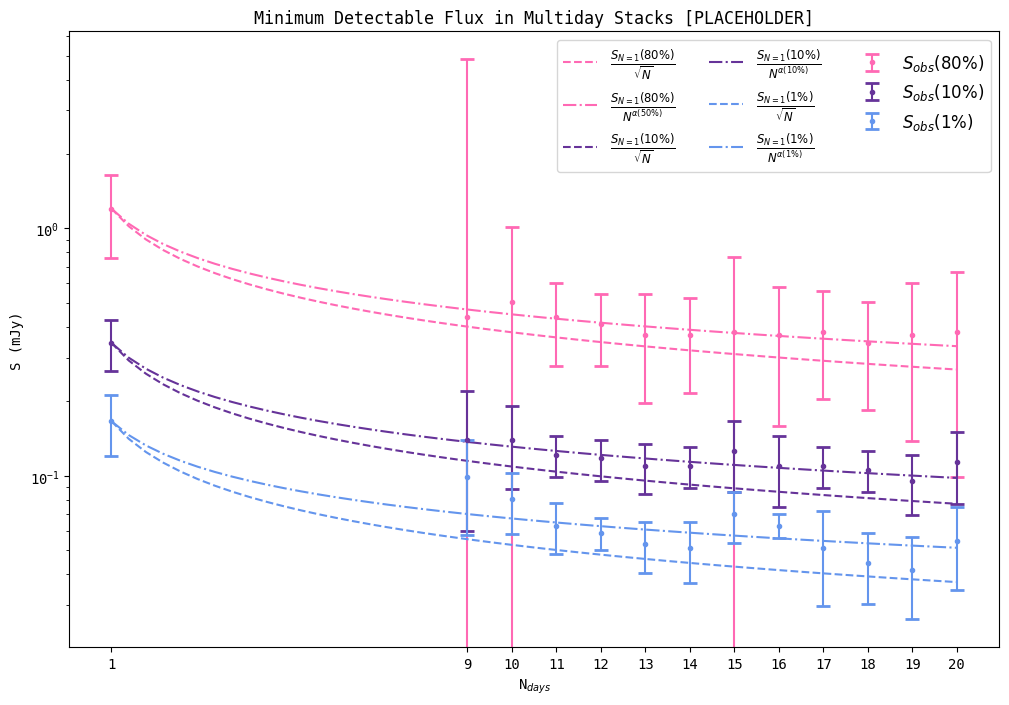

In [577]:
many_days = np.linspace(1, 20)


many_days = np.linspace(1, 20)

fig, ax = plt.subplots(figsize = (12, 8))

plt.errorbar(days, S_80, yerr = S_err50_up, label = r'$S_{obs}(80\%)$', color = 'hotpink',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_80[0] / np.sqrt(many_days), '--', color = 'hotpink',
         label = r'$\frac{S_{N = 1}(80\%)}{\sqrt{N}}$')
plt.plot(many_days, S_80[0] * many_days**alpha_80, '-.', color = 'hotpink',
         label = r'$\frac{S_{N = 1}(80\%)}{N^{\alpha(50\%)}}$')
plt.errorbar(days, S_10, yerr = S_err10_up, label = r'$S_{obs}(10\%)$', color = 'rebeccapurple',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_10[0] / np.sqrt(many_days), '--', color = 'rebeccapurple',
         label = r'$\frac{S_{N = 1}(10\%)}{\sqrt{N}}$')
plt.plot(many_days, S_10[0] * many_days**alpha_10, '-.', color = 'rebeccapurple',
         label = r'$\frac{S_{N = 1}(10\%)}{N^{\alpha(10\%)}}$')
plt.errorbar(days, S_1, yerr = S_err1_up, label = r'$S_{obs}(1\%)$', color = 'cornflowerblue',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_1[0] / np.sqrt(many_days), '--', color = 'cornflowerblue',
         label = r'$\frac{S_{N=1}(1\%)}{\sqrt{N}}$')
plt.plot(many_days, S_1[0] * many_days**alpha_1, '-.', color = 'cornflowerblue',
         label = r'$\frac{S_{N=1}(1\%)}{N^{\alpha(1\%)}}$')
plt.xlabel(r'N$_{days}$')
plt.ylabel('S (mJy)')
plt.legend(fontsize = 12, ncol = 3)
plt.title('Minimum Detectable Flux in Multiday Stacks [PLACEHOLDER]')
xticks = plt.xticks(days) 
plt.yscale('log')

$$S_N = S_1 N^{-0.4}$$
$$N = \left(\frac{S_N}{S_1} \right)^{-2.5} $$

In [548]:
def days_to_Smin(Smin, S1, alpha = 0.39):

    return (Smin / S1)**(-2.5)

Text(0.5, 1.0, 'Estimated Days to Reach Different Retrieval Percentages in CHAMPSS')

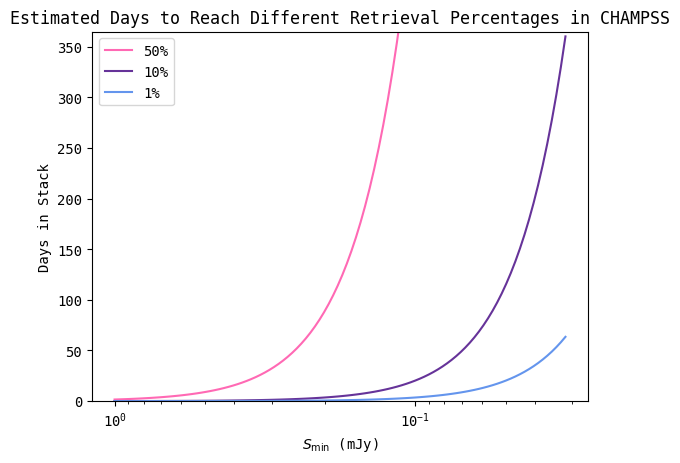

In [549]:
Smin = np.logspace(0, -1.5, 100)

plt.plot(Smin, days_to_Smin(Smin, S_80[0]), label = '50%', color = 'hotpink')
plt.plot(Smin, days_to_Smin(Smin, S_10[0]), label = '10%', color = 'rebeccapurple')
plt.plot(Smin, days_to_Smin(Smin, S_1[0]), label = '1%', color = 'cornflowerblue')
plt.xlabel(r'$S_{\min}$ (mJy)')
plt.ylabel('Days in Stack')
plt.legend()
plt.xscale('log')
plt.ylim(0, 365)
plt.gca().invert_xaxis()
plt.title('Estimated Days to Reach Different Retrieval Percentages in CHAMPSS')

Lorimer & Kramer:
$$S_{min} = \frac{\beta (T_{sys} + T_{sky})}{G} \frac{1}{\sqrt{N_{pol}\tau \Delta \nu}} \sqrt{\frac{\delta}{1 - \delta}} \text{SNR} $$

Additional harmonic sum term from Cordes & :

$$S_{min} = \frac{\beta (T_{sys} + T_{sky})}{G} \frac{1}{\sqrt{N_{pol}\tau \Delta \nu}} \sqrt{\frac{\delta}{1 - \delta}} \left( \frac{\sqrt{N_h}}{\sum_{l = 1}^{N_h} R_l^2} \right) \text{SNR}$$
where
$$R_l = \left| \frac{\~{s}_{eff}(l)}{\~{s}_{eff}(0)} \right|$$
where
$$\~{s}_eff(l) = \~s(l)\~s_d(l)$$

Assuming that we will find >80% of everything with SNR > 10, and choosing $b = 0^{\circ}$ and $l = 90^{\circ}$:

In [ ]:
TSKY = 26 #K
GAIN = 1.16e-3  # K mJy^-1
TSYS = 30  # K
BETA = 1.1
NPOL = 2
TAU = 20* 10 * 60 #s
DELTA_NU = 400e6 #HZ
F_NYQUIST = 508 #Hz

#envelope functions:
def get_nchans(maxdm):
    """
    Inputs a pointing dict with ra, dec, maxdm and returns nchans.

    Inputs
    pointing - A dict of ra, dec, maxdm
    """
    if maxdm <= 212.5:
        nchans = 1024
    elif maxdm <= 425:
        nchans = 2048
    elif maxdm <= 850:
        nchans = 4096
    elif maxdm <= 1700:
        nchans = 8192
    else:
        nchans = 16384
    return nchans


def get_Weff(maxdm):
    
    nchan = str(get_nchans(maxdm))
    delta_DM = 0.1 #pc / cm^-3
    delta_nu = 400 / nchan
    W_eff = DM_CONSTANT * delta_DM * delta_nu / 600**3
    #     = pc cm^-3 MHz * pc cm^-3 * MHz * MHz^-3
    
    return W_eff

def time_windowing(prof_fft, f):
    # apply Van der Klis Eq 2.19 for time-bin windowing effect
    harmonic_freqs = np.arange(1, len(prof_fft) + 1) * f
    B = np.sinc(harmonic_freqs * TSAMP)
    prof_fft *= B

    return prof_fft



def radiometer(f, DM, SNR, FWHM, maxDM, Ndays = 1):

    tau = Ndays * 10 * 60
    N_harm = int(np.floor(F_NYQUIST / f))
    if 32 < N_harm:
        N_harm = 32
 
    FWHM = np.sqrt(FWHM**2 + t_eff**2)

    system_terms =  BETA * (TSYS + TSKY) / GAIN
    obs_terms = 1 / np.sqrt(NPOL * tau * DELTA_NU)
    pulse_terms = np.sqrt(FWHM / (1 - FWHM))

    return system_terms * obs_terms * pulse_terms * SNR

def get_Scurve(f, DM, maxDM, SNR = 6, FWHM = 0.01):

    Smin = np.zeros((len(DM), len(f)))

    for k in range(len(DM)):
        for l in range(len(f)):
            S_temp = radiometer(f[l], DM[k], SNR, FWHM, maxDM) * 1000 #convert to mJy
            Smin[k, l] = S_temp
    return Smin


0.01
0.010125014950048507


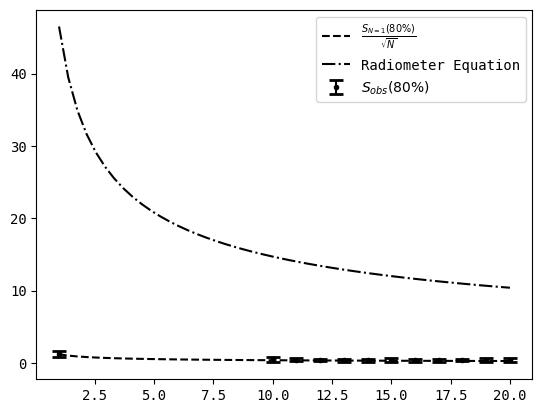

In [564]:
N = np.arange(1, 20)

Smin = radiometer(1, 50, 6, 0.01, 354, many_days) *1000 #convert to mJy

#plt.plot(N, Smin)
plt.errorbar(days, S_80, yerr = S_err50_up, label = r'$S_{obs}(80\%)$', color = 'black',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_80[0] / np.sqrt(many_days), '--', color = 'black',
         label = r'$\frac{S_{N = 1}(80\%)}{\sqrt{N}}$')
plt.plot(many_days, Smin, '-.', color = 'black',
         label = 'Radiometer Equation')
plt.legend()

0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708
0.01
0.01004823305191708


Text(0.5, 0.98, 'Analytical Radiometer Predictions for CHAMPSS Sensitivity')

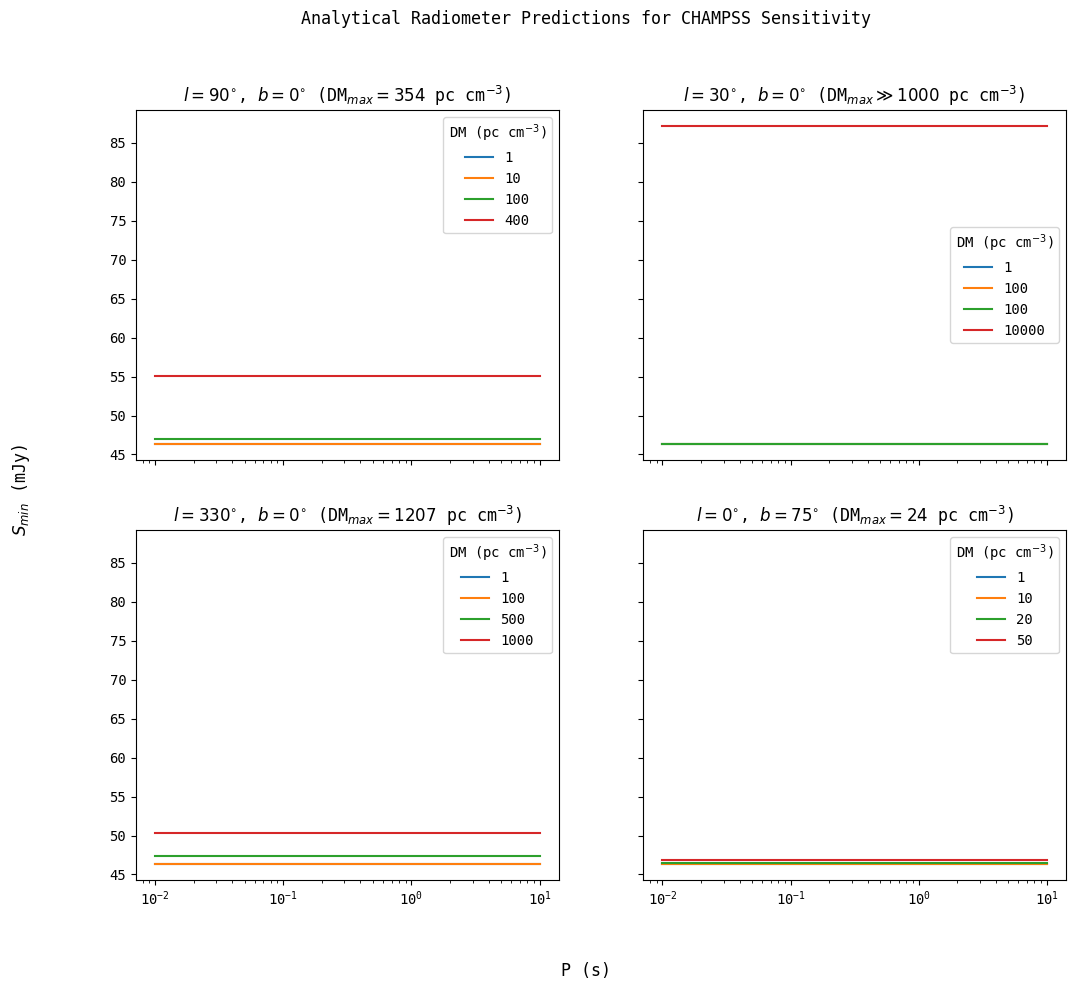

In [565]:
DM = np.array([[1, 10, 100, 400], #where we've found the most pulsars (l = 90, b = 0)
                [1, 100, 100, 10000], #towards the galactic center, plane (l = 30, b = 0)
                [1, 100, 500, 1000], #away from the galactic center, plane (l = 330, b = 0)
                [1, 10, 20, 50], #out of the plane (l = 0, b = 75)
               ])
maxDMs = np.array([354, 10000, 1207, 24])
f = np.logspace(-1, 2, 500)
P = 1 / f

fig, ax = plt.subplots(2, 2, figsize = (12, 10), sharex = True, sharey = True)
ax = ax.flatten()

for i in range(len(maxDMs)):
    Scurve = get_Scurve(f, DM[i], maxDMs[i])
    for j in range(len(Scurve)):
        ax[i].plot(P, Scurve[j], label = int(DM[i, j]))


ax[0].set_xscale('log')
ax[0].legend(title = r'DM (pc cm$^{-3}$)')
ax[0].set_title(r'$l = 90^{\circ}$, $b = 0^{\circ}$ (DM$_{max} = 354$ pc cm$^{-3}$)')
#ax[0].set_ylim(0.5, 10)

ax[1].set_xscale('log')
ax[1].legend(title = r'DM (pc cm$^{-3}$)')
ax[1].set_title(r'$l = 30^{\circ}$, $b = 0^{\circ}$ (DM$_{max} \gg 1000 $ pc cm$^{-3}$)')

ax[2].set_xscale('log')
ax[2].legend(title = r'DM (pc cm$^{-3}$)')
ax[2].set_title(r'$l = 330^{\circ}$, $b = 0^{\circ}$ (DM$_{max} = 1207 $ pc cm$^{-3}$)')

ax[3].set_xscale('log')
ax[3].legend(title = r'DM (pc cm$^{-3}$)')
ax[3].set_title(r'$l = 0^{\circ}$, $b = 75^{\circ}$ (DM$_{max} = 24 $ pc cm$^{-3}$)')

fig.supylabel('$S_{min}$ (mJy)')
fig.supxlabel('P (s)')
fig.suptitle('Analytical Radiometer Predictions for CHAMPSS Sensitivity')
